# Pipeline — Index & Query with SigLIP2 · LanceDB · SAM3 / Grounding DINO

This notebook exercises the full `src` pipeline end-to-end:

1. **Indexing** — `Indexer.from_config()` embeds all RGB frames of a TUM RGB-D benchmark with SigLIP2 and stores vectors in LanceDB.
2. **Querying** — `Search2D.from_config(detector=...)` runs a text query through the four-step LCEL chain:
   `EmbedQuery → RetrieveSimilar → Detect → RerankByDetection`
   The detector is duck-typed: pass `detector="sam"` for SAM3 (returns masks) or `detector="grounding_dino"` for Grounding DINO (returns labels).
3. **Visualisation** — the top-*k* results are displayed with bounding boxes (and SAM3 mask overlays when available), similarity score and detection confidence score.

## Setup

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont

# ── ensure project root is on sys.path and is the working directory ──────────
PROJECT_ROOT = Path("__file__").resolve().parent.parent
if not (PROJECT_ROOT / "config.yaml").exists():
    PROJECT_ROOT = Path("__file__").resolve().parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Project root : {PROJECT_ROOT}")
print(f"Using device : {device}")

Project root : /home/jan/AppliedFoundationModels
Using device : cuda


## Benchmark Selection

Run **exactly one** of the cells below to choose which TUM RGB-D sequence to index, then continue.

In [ ]:
# ── fr1 / desk ────────────────────────────────────────────────────────────────
BENCHMARK  = "rgbd_dataset_freiburg1_desk"
COLLECTION = "fr1_desk"

In [ ]:
# ── fr1 / room ────────────────────────────────────────────────────────────────
BENCHMARK  = "rgbd_dataset_freiburg1_room"
COLLECTION = "fr1_room"

In [2]:
# ── fr2 / desk ────────────────────────────────────────────────────────────────
BENCHMARK  = "rgbd_dataset_freiburg2_desk"
COLLECTION = "fr2_desk"

In [ ]:
# ── fr3 / long_office_household ───────────────────────────────────────────────
BENCHMARK  = "rgbd_dataset_freiburg3_long_office_household"
COLLECTION = "fr3_office"

## Indexing

Parse all RGB frames from `rgb.txt`, then feed them to `Indexer.insert()`.  
The indexer embeds images in batches with SigLIP2 and writes vectors to LanceDB.

> **Skip this section** if the collection is already indexed — `Search2D` will use whatever rows are already in LanceDB.

In [3]:
import yaml
from src.utils.db import connect as db_connect

cfg      = yaml.safe_load(Path("config.yaml").read_text())
db       = db_connect(cfg["indexing"]["db_path"])
data_dir = Path("data/tum") / BENCHMARK

def parse_tum_rgb(data_dir: Path) -> list[dict]:
    """Parse TUM rgb.txt into a list of {path, ts} dicts."""
    entries = []
    for line in (data_dir / "rgb.txt").read_text().splitlines():
        if line.startswith("#") or not line.strip():
            continue
        ts, rel = line.split(maxsplit=1)
        entries.append({"path": str(data_dir / rel.strip()), "ts": float(ts)})
    return entries

frames = parse_tum_rgb(data_dir)
print(f"Benchmark : {BENCHMARK}")
print(f"Collection: {COLLECTION}")
print(f"Frames    : {len(frames):,}")

Benchmark : rgbd_dataset_freiburg2_desk
Collection: fr2_desk
Frames    : 2,965


In [4]:
from src.index import Indexer, get_status

if COLLECTION in db.list_tables().tables:
    n_rows = db.open_table(COLLECTION).count_rows()
    print(f"Collection '{COLLECTION}' already exists with {n_rows:,} rows — skipping indexing.")
else:
    print(f"Collection '{COLLECTION}' not found — starting indexing …")
    idx        = Indexer.from_config("config.yaml")
    paths      = [f["path"] for f in frames]
    timestamps = [f["ts"]   for f in frames]

    job    = idx.insert(paths, COLLECTION, timestamps=timestamps)
    status = get_status(job.job_id)
    print(f"Job finished — state: {status['state']}")
    print(f"Processed {status['processed']}/{status['total']} frames")

Collection 'fr2_desk' not found — starting indexing …


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Indexing 'fr2_desk':   0%|          | 0/2965 [00:00<?, ?img/s]

Job finished — state: done
Processed 2965/2965 frames


## Query — SAM3 path

Edit `QUERY` (and optionally the `TOP_K_*` parameters) before running the two cells below.

**Cell 1** builds the pipeline — loads SigLIP2 and SAM3 once.
**Cell 2** runs the query and stores the result in `state`.

In [5]:
from src.query.pipeline import Search2D

pipeline = Search2D.from_config("config.yaml", detector="sam")
print("SAM pipeline ready.")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

SAM pipeline ready.


In [8]:
QUERY          = "find a ball on the desk"   # ← change to anything
TOP_K_RETRIEVE = 10                    # candidate pool fetched from LanceDB
TOP_K_FINAL    = 5                    # results kept after re-ranking

print(f"Running pipeline for: '{QUERY}' …")
state = pipeline.invoke(
    query=QUERY,
    collection_id=COLLECTION,
    top_k_retrieve=TOP_K_RETRIEVE,
    top_k_final=TOP_K_FINAL,
)

print(f"Retrieved : {len(state.retrieved)} candidates")
print(f"Detected  : {len(state.detected)} images")
print(f"Final hits: {len(state.results)}")

Running pipeline for: 'find a ball on the desk' …
Retrieved : 10 candidates
Detected  : 10 images
Final hits: 5


## Results — SAM3

Top-*k* hits after SAM3 re-ranking, visualised with:
- **Coloured mask overlays** — one colour per SAM3 segment
- **Bounding boxes** labelled with the query text and per-segment confidence score
- **Title** — rank · SigLIP similarity score · SAM3 detection score

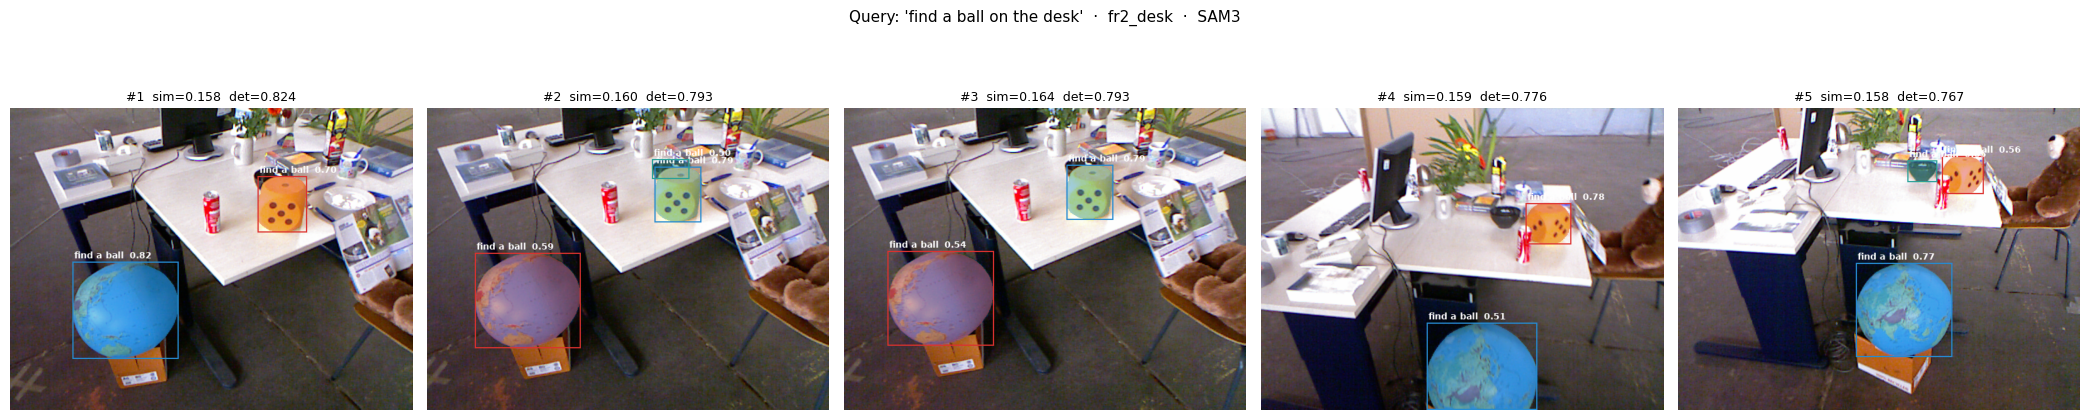

In [9]:
# ── palette & helper ─────────────────────────────────────────────────────────
PALETTE = [
    (220,  50,  47),
    ( 38, 139, 210),
    ( 42, 161, 152),
    (133, 153,   0),
    (211,  54, 130),
    (181, 137,   0),
    (108, 113, 196),
    (203,  75,  22),
]
MASK_ALPHA = 110   # 0–255


def annotate_image(img, masks, boxes, scores, label):
    """Apply SAM3 mask overlays and bounding-box annotations to *img*."""
    canvas = img.convert("RGBA")
    for i, mask in enumerate(masks):
        color   = PALETTE[i % len(PALETTE)]
        mask_np = mask.cpu().numpy().astype(np.uint8)
        overlay = np.zeros((*mask_np.shape, 4), dtype=np.uint8)
        overlay[mask_np > 0] = [*color, MASK_ALPHA]
        canvas = Image.alpha_composite(canvas, Image.fromarray(overlay, "RGBA"))

    if len(masks) > 0:
        draw = ImageDraw.Draw(canvas)
        try:
            font = ImageFont.truetype(
                "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", size=14
            )
        except OSError:
            font = ImageFont.load_default()
        for i, (score, box) in enumerate(zip(scores, boxes)):
            color          = PALETTE[i % len(PALETTE)]
            x0, y0, x1, y1 = [int(v) for v in box.tolist()]
            draw.rectangle([x0, y0, x1, y1], outline=(*color, 255), width=2)
            draw.text(
                (x0 + 3, max(y0 - 18, 0)),
                f"{label[:12]} {float(score):.2f}",
                fill=(255, 255, 255, 255),
                font=font,
            )
    return canvas.convert("RGB")


# ── plot ─────────────────────────────────────────────────────────────────────
n = len(state.results)
fig, axes = plt.subplots(1, n, figsize=(n * 4.2, 4.5), squeeze=False)

for rank, (ax, hit) in enumerate(zip(axes[0], state.results), start=1):
    img = Image.open(hit.path).convert("RGB")
    annotated = annotate_image(
        img,
        masks=hit.masks,
        boxes=hit.boxes,
        scores=hit.scores,
        label=QUERY,
    )
    ax.imshow(np.array(annotated))
    ax.set_title(
        f"#{rank}  sim={hit.similarity_score:.3f}  det={hit.detection_score:.3f}",
        fontsize=9,
    )
    ax.axis("off")

plt.suptitle(f"Query: '{QUERY}'  ·  {COLLECTION}  ·  SAM3", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Query — Grounding DINO path

Same chain, different detector. `Search2D.from_config(detector="grounding_dino")` wires `GroundingDINOModel` in place of SAM. The result objects come back with `labels` populated and `masks=None`, so the visualisation below renders bounding boxes only — no mask overlay.

For DINO the query should be a dot-separated list of category names (e.g. `"laptop . monitor . keyboard"`). A trailing period is added automatically by the wrapper, but multiple categories help DINO disambiguate.

In [ ]:
from src.query.pipeline import Search2D

pipeline_dino = Search2D.from_config("config.yaml", detector="grounding_dino")
print("Grounding DINO pipeline ready.")

In [ ]:
QUERY_DINO     = "laptop"   # dot-separated categories
TOP_K_RETRIEVE = 10
TOP_K_FINAL    = 5

print(f"Running DINO pipeline for: '{QUERY_DINO}' …")
state_dino = pipeline_dino.invoke(
    query=QUERY_DINO,
    collection_id=COLLECTION,
    top_k_retrieve=TOP_K_RETRIEVE,
    top_k_final=TOP_K_FINAL,
)

print(f"Retrieved : {len(state_dino.retrieved)} candidates")
print(f"Detected  : {len(state_dino.detected)} images")
print(f"Final hits: {len(state_dino.results)}")

## Results — Grounding DINO

Box-only visualisation: DINO returns no masks, so each detection is drawn as a labelled rectangle (`label score`) on the source frame.

In [ ]:
def annotate_boxes_only(img, boxes, scores, labels):
    """Draw labelled bounding boxes (no masks) on *img*."""
    canvas = img.convert("RGBA")
    if len(boxes) == 0:
        return canvas.convert("RGB")

    draw = ImageDraw.Draw(canvas)
    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", size=14
        )
    except OSError:
        font = ImageFont.load_default()

    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        color          = PALETTE[i % len(PALETTE)]
        x0, y0, x1, y1 = [int(v) for v in box.tolist()]
        draw.rectangle([x0, y0, x1, y1], outline=(*color, 255), width=2)
        draw.text(
            (x0 + 3, max(y0 - 18, 0)),
            f"{str(label)[:14]} {float(score):.2f}",
            fill=(255, 255, 255, 255),
            font=font,
        )
    return canvas.convert("RGB")


# ── plot ─────────────────────────────────────────────────────────────────────
n = len(state_dino.results)
fig, axes = plt.subplots(1, n, figsize=(n * 4.2, 4.5), squeeze=False)

for rank, (ax, hit) in enumerate(zip(axes[0], state_dino.results), start=1):
    img = Image.open(hit.path).convert("RGB")
    annotated = annotate_boxes_only(
        img,
        boxes=hit.boxes,
        scores=hit.scores,
        labels=hit.labels or [],
    )
    ax.imshow(np.array(annotated))
    ax.set_title(
        f"#{rank}  sim={hit.similarity_score:.3f}  det={hit.detection_score:.3f}",
        fontsize=9,
    )
    ax.axis("off")

plt.suptitle(f"Query: '{QUERY_DINO}'  ·  {COLLECTION}  ·  Grounding DINO", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()